# 1. Project Overview

This notebook performs dataset inspection, preprocessing, and feature engineering for a **binary structural damage classification** project using the PEER Φ-Net Task 2 dataset.

## Goal
Prepare image data and **HOG feature vectors** for downstream classical machine-learning models:
- **SVM**
- **Logistic Regression**

## Dataset
- **Source**: PEER Φ-Net Task 2 (damage-state classification)
- **Task 2_1 / Task 2_2 files** are combined as downloaded: the labelled training/test arrays are distributed across the two folders.

## What This Notebook Produces
- A reproducible **stratified train/validation/test split**
- Memory-safe image preprocessing
- **HOG feature arrays** saved to `results/`
- A **StandardScaler** fitted only on training HOG features
- Data-leakage verification

> **Note:** No model training occurs in this notebook. The original dataset files are never modified.


In [2]:
import sys
print(sys.version)
print(sys.executable)

3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
c:\Users\Noothan\Documents\my_work\structural-damage-classification\.venv\Scripts\python.exe


In [3]:
import skimage
print(skimage.__version__)

0.26.0


## 2. Imports

In [4]:
# ── Imports ───────────────────────────────────────────────────────────────────

import os
import pathlib
import joblib
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from skimage.feature import hog as skimage_hog
from skimage import exposure
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

%matplotlib inline

print("All required libraries imported successfully.")


## 3. Dataset Paths & Configuration

In [5]:
# ── Reproducibility and Configuration ─────────────────────────────────────────

SEED = 42
VAL_FRACTION = 0.15
BATCH_SIZE = 256

# HOG configuration
HOG_PIXELS_PER_CELL = (8, 8)
HOG_CELLS_PER_BLOCK = (2, 2)
HOG_ORIENTATIONS = 9

# Project paths
DATA_DIR = pathlib.Path("../data")
RESULTS_DIR = pathlib.Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"DATA_DIR    : {DATA_DIR.resolve()}")
print(f"RESULTS_DIR : {RESULTS_DIR.resolve()}")
print(f"SEED={SEED} | VAL_FRACTION={VAL_FRACTION} | BATCH_SIZE={BATCH_SIZE}")
print(
    f"HOG pixels_per_cell={HOG_PIXELS_PER_CELL} | "
    f"cells_per_block={HOG_CELLS_PER_BLOCK} | "
    f"orientations={HOG_ORIENTATIONS}"
)


DATA_DIR    : C:\Users\Noothan\Documents\my_work\structural-damage-classification\data
RESULTS_DIR : C:\Users\Noothan\Documents\my_work\structural-damage-classification\results
SEED=42 | VAL_FRACTION=0.15 | BATCH_SIZE=256
HOG pixels_per_cell=(8, 8) | cells_per_block=(2, 2) | orientations=9


In [6]:
from pathlib import Path

data_dir = Path("../data")

print("Task 2_1:")
for f in (data_dir / "task2_damage_state_1").iterdir():
    print(f.name)

print("\nTask 2_2:")
for f in (data_dir / "task2_damage_state_2").iterdir():
    print(f.name)

Task 2_1:
license.txt
README.txt
task2_X_test.npy
task2_y_test.npy
task2_y_train.npy

Task 2_2:
task2_X_train.npy


## 4. Dataset Inspection

In [7]:
# ── Task 2: File existence and size check ─────────────────────────────────────
#
# Define the 5 required dataset files. Paths are relative to the notebook
# location (notebooks/), so the data root is one level up (../data/).

REQUIRED_FILES = {
    "X_train": DATA_DIR / "task2_damage_state_2" / "task2_X_train.npy",
    "y_train": DATA_DIR / "task2_damage_state_1" / "task2_y_train.npy",
    "X_test":  DATA_DIR / "task2_damage_state_1" / "task2_X_test.npy",
    "y_test":  DATA_DIR / "task2_damage_state_1" / "task2_y_test.npy",
}

# --- Existence check ---
missing = [str(path) for path in REQUIRED_FILES.values() if not path.exists()]

if missing:
    raise RuntimeError(
        "The following required dataset files are missing:\n"
        + "\n".join(f"  - {p}" for p in missing)
    )

print("All required files are present.\n")

# --- File size display (MB, 2 decimal places) ---
print(f"{'Label':<20}  {'Path':<65}  {'Size (MB)':>10}")
print("-" * 100)
for label, path in REQUIRED_FILES.items():
    size_mb = path.stat().st_size / (1024 ** 2)
    print(f"{label:<20}  {str(path):<65}  {size_mb:>10.2f}")

All required files are present.

Label                 Path                                                                Size (MB)
----------------------------------------------------------------------------------------------------
X_train               ..\data\task2_damage_state_2\task2_X_train.npy                        6782.10
y_train               ..\data\task2_damage_state_1\task2_y_train.npy                           0.09
X_test                ..\data\task2_damage_state_1\task2_X_test.npy                          838.36
y_test                ..\data\task2_damage_state_1\task2_y_test.npy                            0.01


In [8]:
X_train = np.load(REQUIRED_FILES["X_train"], mmap_mode="r")
y_train = np.load(REQUIRED_FILES["y_train"], mmap_mode="r")

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Same number of samples:", X_train.shape[0] == y_train.shape[0])

X_train shape: (11811, 224, 224, 3)
y_train shape: (11811, 2)
Same number of samples: True


In [9]:
# ── Task 3: Safe array shape and dtype inspection ─────────────────────────────
#
# Actual dataset structure:
#
# task2_damage_state_1/
#   ├── task2_y_train.npy
#   ├── task2_X_test.npy
#   └── task2_y_test.npy
#
# task2_damage_state_2/
#   └── task2_X_train.npy
#
# X_train is large (~6.8 GB), so it is loaded with mmap_mode='r'.
# The other arrays are loaded normally.

import numpy as np


# ── Helper function ──────────────────────────────────────────────────────────

def inspect_array(name, arr):
    """Display shape, dtype, pixel range, and image dimensions."""

    print("\n" + "─" * 70)
    print(f"Array : {name}")
    print(f"Shape : {arr.shape}")
    print(f"dtype : {arr.dtype}")

    # Shape information
    if arr.ndim == 4:
        N, H, W, C = arr.shape
        print(f"Dims  : N={N}, H={H}, W={W}, C={C}")

    elif arr.ndim == 3:
        N, H, W = arr.shape
        print(f"Dims  : N={N}, H={H}, W={W}, C=1")

    elif arr.ndim == 2:
        print(f"Dims  : 2-D array (likely labels)")

    elif arr.ndim == 1:
        print(f"Dims  : 1-D array")

    # Pixel range only for image arrays
    if arr.ndim >= 3:

        arr_min = float(arr.min())
        arr_max = float(arr.max())

        print(f"Min   : {arr_min}")
        print(f"Max   : {arr_max}")

        if (
            arr_min >= 0
            and arr_max <= 255
        ):
            print("Range : [0, 255] ✓")

        elif (
            arr_min >= 0.0
            and arr_max <= 1.0
        ):
            print("Range : [0.0, 1.0] ✓")

        else:
            print(
                f"⚠ WARNING: Unexpected pixel range "
                f"[{arr_min}, {arr_max}]"
            )

    # Label information
    if arr.ndim <= 2:
        print("Unique values / rows:")

        try:
            if arr.ndim == 1:
                print(np.unique(arr))

            elif arr.ndim == 2:
                print(np.unique(arr, axis=0))

        except Exception as e:
            print(f"Could not determine unique values: {e}")


# ── Load arrays from the ACTUAL dataset locations ────────────────────────────

print("Loading X_train using memory mapping...")
print("This avoids loading the ~6.8 GB file completely into RAM.")

X_train = np.load(
    DATA_DIR / "task2_damage_state_2" / "task2_X_train.npy",
    mmap_mode="r"
)

print("Loading y_train...")
y_train = np.load(
    DATA_DIR / "task2_damage_state_1" / "task2_y_train.npy"
)

print("Loading X_test...")
X_test = np.load(
    DATA_DIR / "task2_damage_state_1" / "task2_X_test.npy"
)

print("Loading y_test...")
y_test = np.load(
    DATA_DIR / "task2_damage_state_1" / "task2_y_test.npy"
)

print("\n✓ All available arrays loaded successfully.")


# ── Display array information ────────────────────────────────────────────────

print("\n" + "═" * 70)
print("ARRAY SHAPE / DTYPE / RANGE INSPECTION")
print("═" * 70)

inspect_array("X_train", X_train)
inspect_array("y_train", y_train)
inspect_array("X_test", X_test)
inspect_array("y_test", y_test)


# ── Sample count consistency checks ─────────────────────────────────────────

print("\n" + "═" * 70)
print("SAMPLE COUNT CONSISTENCY CHECKS")
print("═" * 70)

train_match = X_train.shape[0] == y_train.shape[0]
test_match = X_test.shape[0] == y_test.shape[0]

print(
    f"Train: X_train={X_train.shape[0]}, "
    f"y_train={y_train.shape[0]} "
    f"→ {'✓ MATCH' if train_match else '✗ MISMATCH'}"
)

print(
    f"Test : X_test={X_test.shape[0]}, "
    f"y_test={y_test.shape[0]} "
    f"→ {'✓ MATCH' if test_match else '✗ MISMATCH'}"
)


# ── Stop if image/label counts don't match ──────────────────────────────────

if not train_match:
    raise RuntimeError(
        f"Training mismatch: X_train has {X_train.shape[0]} samples "
        f"but y_train has {y_train.shape[0]} labels."
    )

if not test_match:
    raise RuntimeError(
        f"Test mismatch: X_test has {X_test.shape[0]} samples "
        f"but y_test has {y_test.shape[0]} labels."
    )


# ── Final summary ────────────────────────────────────────────────────────────

print("\n" + "═" * 70)
print("TASK 3 COMPLETE")
print("═" * 70)

print(f"Training images : {X_train.shape}")
print(f"Training labels : {y_train.shape}")
print(f"Test images     : {X_test.shape}")
print(f"Test labels     : {y_test.shape}")

print("\n✓ Training image/label counts match.")
print("✓ Test image/label counts match.")
print("✓ X_train was loaded using memory mapping.")

Loading X_train using memory mapping...
This avoids loading the ~6.8 GB file completely into RAM.
Loading y_train...
Loading X_test...
Loading y_test...

✓ All available arrays loaded successfully.

══════════════════════════════════════════════════════════════════════
ARRAY SHAPE / DTYPE / RANGE INSPECTION
══════════════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────────────
Array : X_train
Shape : (11811, 224, 224, 3)
dtype : float32
Dims  : N=11811, H=224, W=224, C=3
Min   : -123.68000030517578
Max   : 151.06100463867188
⚠ WARNING: Unexpected pixel range [-123.68000030517578, 151.06100463867188]

──────────────────────────────────────────────────────────────────────
Array : y_train
Shape : (11811, 2)
dtype : float32
Dims  : 2-D array (likely labels)
Unique values / rows:
[[0. 1.]
 [1. 0.]]

──────────────────────────────────────────────────────────────────────
Array : X_test
Shape : (1460, 224, 224, 3)
dtype : 

In [10]:
# ── Task 4: Class Distribution ───────────────────────────────────────────────

def class_distribution_report(name, labels, images=None):

    print("\n" + "═" * 70)
    print(f"CLASS DISTRIBUTION — {name}")
    print("═" * 70)

    # Convert one-hot labels to class indices if necessary
    if labels.ndim == 2:
        class_indices = np.argmax(labels, axis=1)
    else:
        class_indices = labels

    unique_classes, counts = np.unique(
        class_indices,
        return_counts=True
    )

    total = len(class_indices)

    print(f"Total samples: {total}\n")

    for cls, count in zip(unique_classes, counts):
        percentage = (count / total) * 100

        print(
            f"Class {cls}: "
            f"{count:,} samples "
            f"({percentage:.2f}%)"
        )

    # Check whether the dataset is reasonably balanced
    if len(counts) == 2:
        ratio = min(counts) / max(counts)

        print(f"\nClass balance ratio: {ratio:.3f}")

        if ratio >= 0.8:
            print("✓ Classes are reasonably balanced.")
        else:
            print("⚠ Dataset shows some class imbalance.")


# ── Generate reports ─────────────────────────────────────────────────────────

class_distribution_report(
    "Train",
    y_train,
    X_train
)

class_distribution_report(
    "Test",
    y_test,
    X_test
)


══════════════════════════════════════════════════════════════════════
CLASS DISTRIBUTION — Train
══════════════════════════════════════════════════════════════════════
Total samples: 11811

Class 0: 6,282 samples (53.19%)
Class 1: 5,529 samples (46.81%)

Class balance ratio: 0.880
✓ Classes are reasonably balanced.

══════════════════════════════════════════════════════════════════════
CLASS DISTRIBUTION — Test
══════════════════════════════════════════════════════════════════════
Total samples: 1460

Class 0: 745 samples (51.03%)
Class 1: 715 samples (48.97%)

Class balance ratio: 0.960
✓ Classes are reasonably balanced.


## 5. Task 2_1 vs Task 2_2 Comparison

In [13]:
# ── Task 5: Task 2_1 vs Task 2_2 Comparison ──────────────────────────────────
#
# Actual downloaded structure:
#
# task2_damage_state_1/
#   ├── task2_y_train.npy
#   ├── task2_X_test.npy
#   ├── task2_y_test.npy
#   ├── README.txt
#   └── license.txt
#
# task2_damage_state_2/
#   └── task2_X_train.npy
#
# Therefore:
#   X_train → Task 2_2
#   y_train → Task 2_1
#   X_test  → Task 2_1
#   y_test  → Task 2_1
#
# Task 2_2 has X_train but no labels.
# ─────────────────────────────────────────────────────────────────────────────


from pathlib import Path
import numpy as np


# ══════════════════════════════════════════════════════════════════════════════
# 1. DEFINE DATA DIRECTORY
# ══════════════════════════════════════════════════════════════════════════════

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

task21_dir = DATA_DIR / "task2_damage_state_1"
task22_dir = DATA_DIR / "task2_damage_state_2"

print("Project root :", PROJECT_ROOT)
print("Data directory:", DATA_DIR)

if not task21_dir.exists():
    raise FileNotFoundError(
        f"Task 2_1 folder not found:\n{task21_dir}"
    )

if not task22_dir.exists():
    raise FileNotFoundError(
        f"Task 2_2 folder not found:\n{task22_dir}"
    )

print("✓ Dataset folders found.")


# ══════════════════════════════════════════════════════════════════════════════
# 2. SHOW FILES
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "═" * 70)
print("TASK 2_1 FILES")
print("═" * 70)

for file in sorted(task21_dir.iterdir()):
    print(" ", file.name)


print("\n" + "═" * 70)
print("TASK 2_2 FILES")
print("═" * 70)

for file in sorted(task22_dir.iterdir()):
    print(" ", file.name)


# ══════════════════════════════════════════════════════════════════════════════
# 3. HELPER FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

def file_mb(path):
    """Return file size in MB."""
    if path.exists():
        return path.stat().st_size / (1024 ** 2)
    return None


def get_dims(arr):
    """Return H, W, C from image array."""

    if arr.ndim == 4:
        _, H, W, C = arr.shape
        return H, W, C

    if arr.ndim == 3:
        _, H, W = arr.shape
        return H, W, 1

    return None, None, None


# ══════════════════════════════════════════════════════════════════════════════
# 4. LOAD ARRAYS
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "═" * 70)
print("LOADING DATA")
print("═" * 70)


# X_train is stored in Task 2_2
print("\nLoading X_train...")
X_train = np.load(
    task22_dir / "task2_X_train.npy",
    mmap_mode="r"
)
print("✓ X_train loaded:", X_train.shape)


# y_train is stored in Task 2_1
print("Loading y_train...")
y_train = np.load(
    task21_dir / "task2_y_train.npy"
)
print("✓ y_train loaded:", y_train.shape)


# X_test is stored in Task 2_1
print("Loading X_test...")
X_test = np.load(
    task21_dir / "task2_X_test.npy",
    mmap_mode="r"
)
print("✓ X_test loaded:", X_test.shape)


# y_test is stored in Task 2_1
print("Loading y_test...")
y_test = np.load(
    task21_dir / "task2_y_test.npy"
)
print("✓ y_test loaded:", y_test.shape)


# ══════════════════════════════════════════════════════════════════════════════
# 5. TASK 2_2 X_TRAIN
# ══════════════════════════════════════════════════════════════════════════════

# Task 2_2 contains the same X_train file that is used above.
# We use X_train itself for the comparison.

X_train_22 = X_train


# ══════════════════════════════════════════════════════════════════════════════
# 6. BASIC ATTRIBUTES
# ══════════════════════════════════════════════════════════════════════════════

shape_21 = X_train.shape
shape_22 = X_train_22.shape

H21, W21, C21 = get_dims(X_train)
H22, W22, C22 = get_dims(X_train_22)

dtype_21 = str(X_train.dtype)
dtype_22 = str(X_train_22.dtype)


# IMPORTANT:
# Do NOT scan the entire 6.8 GB array.
# Use only the first 100 images for pixel-range inspection.

sample_21 = np.asarray(X_train[:100])
sample_22 = np.asarray(X_train_22[:100])

pmin_21 = float(sample_21.min())
pmax_21 = float(sample_21.max())

pmin_22 = float(sample_22.min())
pmax_22 = float(sample_22.max())


# ══════════════════════════════════════════════════════════════════════════════
# 7. LABEL INFORMATION
# ══════════════════════════════════════════════════════════════════════════════

# y_train and y_test may be one-hot encoded.
# Convert them to class IDs if necessary.

if y_train.ndim == 2:
    labels_train = np.argmax(y_train, axis=1)
else:
    labels_train = y_train.astype(int)


if y_test.ndim == 2:
    labels_test = np.argmax(y_test, axis=1)
else:
    labels_test = y_test.astype(int)


labels_21 = sorted(
    set(np.unique(labels_train).tolist())
    |
    set(np.unique(labels_test).tolist())
)

labels_22 = "N/A — no label files"


# ══════════════════════════════════════════════════════════════════════════════
# 8. AVAILABLE SPLITS
# ══════════════════════════════════════════════════════════════════════════════

splits_21 = []

# Task 2_1 does NOT contain X_train in the actual downloaded structure,
# but it contains y_train.
if (
    (task21_dir / "task2_y_train.npy").exists()
    and
    (task22_dir / "task2_X_train.npy").exists()
):
    splits_21.append("train*")


if (
    (task21_dir / "task2_X_test.npy").exists()
    and
    (task21_dir / "task2_y_test.npy").exists()
):
    splits_21.append("test")


splits_22 = []

if (task22_dir / "task2_X_train.npy").exists():
    splits_22.append("X_train only")


# ══════════════════════════════════════════════════════════════════════════════
# 9. FILE SIZES
# ══════════════════════════════════════════════════════════════════════════════

x_train_path = task22_dir / "task2_X_train.npy"

x_test_path = task21_dir / "task2_X_test.npy"

train_size = file_mb(x_train_path)
test_size = file_mb(x_test_path)

train_size_str = (
    f"{train_size:.2f} MB"
    if train_size is not None
    else "Not found"
)

test_size_str = (
    f"{test_size:.2f} MB"
    if test_size is not None
    else "Not found"
)


# ══════════════════════════════════════════════════════════════════════════════
# 10. COMPARISON TABLE
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "═" * 100)
print("TASK 2_1 vs TASK 2_2 COMPARISON")
print("═" * 100)

print(
    f"{'Attribute':<30}"
    f"{'Task 2_1':<35}"
    f"{'Task 2_2':<35}"
)

print("─" * 100)


rows = [

    (
        "X_train",
        "Provided through Task 2_2",
        "Available"
    ),

    (
        "X_train shape",
        str(shape_21),
        str(shape_22)
    ),

    (
        "Spatial dimensions",
        f"{H21} × {W21}",
        f"{H22} × {W22}"
    ),

    (
        "Channels",
        str(C21),
        str(C22)
    ),

    (
        "dtype",
        dtype_21,
        dtype_22
    ),

    (
        "Pixel min (first 100)",
        f"{pmin_21:.4f}",
        f"{pmin_22:.4f}"
    ),

    (
        "Pixel max (first 100)",
        f"{pmax_21:.4f}",
        f"{pmax_22:.4f}"
    ),

    (
        "Available data",
        "Train labels + Test images + Test labels",
        "Train images only"
    ),

    (
        "Label set",
        str(labels_21),
        labels_22
    ),

    (
        "X_train file size",
        train_size_str,
        train_size_str
    ),
]


for attribute, value21, value22 in rows:

    print(
        f"{attribute:<30}"
        f"{value21:<35}"
        f"{value22:<35}"
    )


print("═" * 100)


# ══════════════════════════════════════════════════════════════════════════════
# 11. COMPATIBILITY CHECK
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "═" * 70)
print("COMPATIBILITY CHECK")
print("═" * 70)


if (H21, W21) == (H22, W22):

    print(
        f"✓ Spatial dimensions match: "
        f"{H21} × {W21}"
    )

else:

    print(
        f"⚠ Spatial dimensions differ: "
        f"{H21} × {W21} vs {H22} × {W22}"
    )


if C21 == C22:

    print(
        f"✓ Channel count matches: {C21}"
    )

else:

    print(
        f"⚠ Channel count differs: "
        f"{C21} vs {C22}"
    )


print(
    "⚠ Task 2_2 does not contain label files."
)


# ══════════════════════════════════════════════════════════════════════════════
# 12. DATASET DECISION
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "═" * 70)
print("SELECTED DATASET")
print("═" * 70)

print(
    """
Selected: Task 2_1

Reason:
The Task 2 dataset provides the labelled data required for
supervised binary classification.

In the downloaded files, the training images are stored in
task2_damage_state_2, while the corresponding training labels
are stored in task2_damage_state_1.

Task 2_2 contains the training images but no separate label
file. Therefore, it cannot independently be used for
supervised training.

The labelled Task 2 dataset will therefore be used for the
downstream SVM and Logistic Regression modelling.
"""
)

SELECTED_DATASET = "Task_2_1"

print(
    f"SELECTED_DATASET = {SELECTED_DATASET!r}"
)


# ══════════════════════════════════════════════════════════════════════════════
# 13. FINAL SUMMARY
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "═" * 70)
print("TASK 5 COMPLETE ✓")
print("═" * 70)

print("Training images :", X_train.shape)
print("Training labels :", y_train.shape)
print("Test images     :", X_test.shape)
print("Test labels     :", y_test.shape)

print("\n✓ Task 2_1 / Task 2_2 comparison completed.")
print("✓ No full 6.8 GB array scan was performed.")
print("✓ Task 2_1 selected for supervised modelling.")

Project root : c:\Users\Noothan\Documents\my_work\structural-damage-classification
Data directory: c:\Users\Noothan\Documents\my_work\structural-damage-classification\data
✓ Dataset folders found.

══════════════════════════════════════════════════════════════════════
TASK 2_1 FILES
══════════════════════════════════════════════════════════════════════
  license.txt
  README.txt
  task2_X_test.npy
  task2_y_test.npy
  task2_y_train.npy

══════════════════════════════════════════════════════════════════════
TASK 2_2 FILES
══════════════════════════════════════════════════════════════════════
  task2_X_train.npy

══════════════════════════════════════════════════════════════════════
LOADING DATA
══════════════════════════════════════════════════════════════════════

Loading X_train...
✓ X_train loaded: (11811, 224, 224, 3)
Loading y_train...
✓ y_train loaded: (11811, 2)
Loading X_test...
✓ X_test loaded: (1460, 224, 224, 3)
Loading y_test...
✓ y_test loaded: (1460, 2)

══════════════════

## 6. Class Distribution


═══════════════════════════════════════════════════════════════════════════
CLASS DISTRIBUTION
═══════════════════════════════════════════════════════════════════════════
Split          Class 0             Class 1             Total     
---------------------------------------------------------------------------
Train          6,282 (53.2%)    5,529 (46.8%)    11,811
Test           745 (51.0%)    715 (49.0%)    1,460


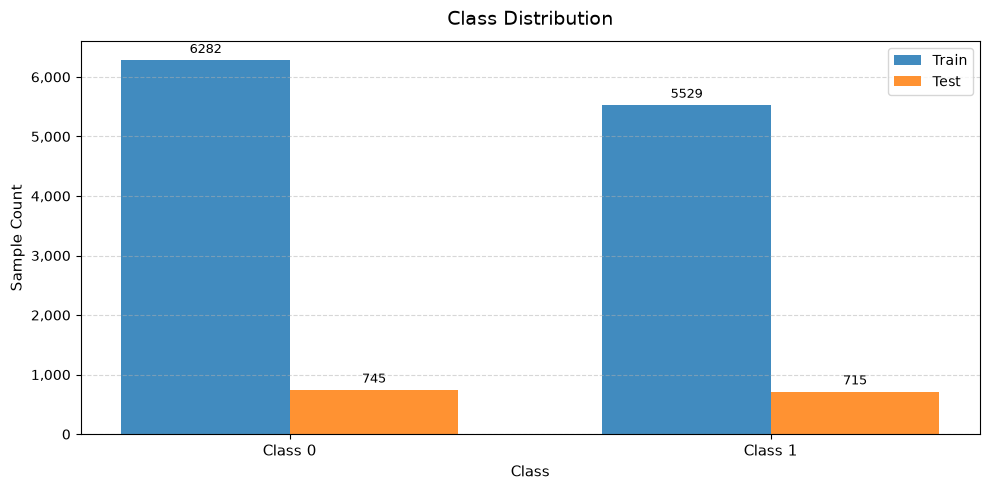


═══════════════════════════════════════════════════════════════════════════
TASK 6 COMPLETE ✓
═══════════════════════════════════════════════════════════════════════════
Training samples: 11811
Test samples: 1460
Class 0: Train=6,282, Test=745
Class 1: Train=5,529, Test=715

Note: Class 0 / Class 1 semantic names will be assigned after verifying the PEER README.


In [15]:
# ── Task 6: Class Distribution Bar Chart ──────────────────────────────────────
#
# Shows the pre-split class distribution for:
#   1. Training pool
#   2. Official test set
#
# Labels are handled automatically if they are one-hot encoded.
# Class names are kept as Class 0 / Class 1 until the README confirms
# the exact semantic mapping.


import numpy as np
import matplotlib.pyplot as plt


# ══════════════════════════════════════════════════════════════════════════════
# 1. MAKE SURE LABELS ARE AVAILABLE
# ══════════════════════════════════════════════════════════════════════════════

# If y_train/y_test already exist, use them.
# Otherwise, load them directly from the actual dataset locations.

if "y_train" not in globals():

    print("Loading y_train...")

    y_train = np.load(
        DATA_DIR
        / "task2_damage_state_1"
        / "task2_y_train.npy"
    )

    print("✓ y_train loaded.")


if "y_test" not in globals():

    print("Loading y_test...")

    y_test = np.load(
        DATA_DIR
        / "task2_damage_state_1"
        / "task2_y_test.npy"
    )

    print("✓ y_test loaded.")


# ══════════════════════════════════════════════════════════════════════════════
# 2. CONVERT ONE-HOT LABELS TO CLASS IDs
# ══════════════════════════════════════════════════════════════════════════════

if y_train.ndim == 2:

    y_train_ids = np.argmax(y_train, axis=1)

else:

    y_train_ids = y_train.astype(int)


if y_test.ndim == 2:

    y_test_ids = np.argmax(y_test, axis=1)

else:

    y_test_ids = y_test.astype(int)


# ══════════════════════════════════════════════════════════════════════════════
# 3. CLASS INFORMATION
# ══════════════════════════════════════════════════════════════════════════════

class_ids = sorted(
    set(np.unique(y_train_ids).tolist())
    |
    set(np.unique(y_test_ids).tolist())
)

# Do NOT assume the semantic meaning yet.
class_names = [
    f"Class {class_id}"
    for class_id in class_ids
]


# ══════════════════════════════════════════════════════════════════════════════
# 4. PREPARE DATA
# ══════════════════════════════════════════════════════════════════════════════

splits_data = {

    "Train": y_train_ids,

    "Test": y_test_ids
}


split_names = list(splits_data.keys())


count_matrix = [

    [
        int(np.sum(y == class_id))
        for class_id in class_ids
    ]

    for y in splits_data.values()
]


# ══════════════════════════════════════════════════════════════════════════════
# 5. PRINT CLASS DISTRIBUTION TABLE
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "═" * 75)
print("CLASS DISTRIBUTION")
print("═" * 75)

print(
    f"{'Split':<15}"
    + "".join(
        f"{name:<20}"
        for name in class_names
    )
    + f"{'Total':<10}"
)

print("-" * 75)


for split_name, counts in zip(
    split_names,
    count_matrix
):

    total = sum(counts)

    values = f"{split_name:<15}"

    for count in counts:

        percentage = (
            count / total * 100
        )

        values += (
            f"{count:,} "
            f"({percentage:.1f}%)    "
        )

    values += f"{total:,}"

    print(values)


# ══════════════════════════════════════════════════════════════════════════════
# 6. CREATE BAR CHART
# ══════════════════════════════════════════════════════════════════════════════

x = np.arange(len(class_names))

n_splits = len(split_names)

width = 0.35

offsets = np.linspace(
    -(n_splits - 1) * width / 2,
    (n_splits - 1) * width / 2,
    n_splits
)


fig, ax = plt.subplots(
    figsize=(10, 5)
)


for i, (
    split_name,
    counts,
    offset
) in enumerate(
    zip(
        split_names,
        count_matrix,
        offsets
    )
):

    bars = ax.bar(
        x + offset,
        counts,
        width=width,
        label=split_name,
        alpha=0.85
    )

    ax.bar_label(
        bars,
        fmt="%d",
        padding=3,
        fontsize=9
    )


# ══════════════════════════════════════════════════════════════════════════════
# 7. CHART FORMATTING
# ══════════════════════════════════════════════════════════════════════════════

ax.set_title(
    "Class Distribution",
    fontsize=14,
    pad=12
)

ax.set_xlabel(
    "Class",
    fontsize=11
)

ax.set_ylabel(
    "Sample Count",
    fontsize=11
)

ax.set_xticks(x)

ax.set_xticklabels(
    class_names,
    fontsize=11
)

ax.legend(
    fontsize=10
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, _: f"{int(value):,}"
    )
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)


plt.tight_layout()

plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# 8. FINAL SUMMARY
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "═" * 75)
print("TASK 6 COMPLETE ✓")
print("═" * 75)

print(
    "Training samples:",
    len(y_train_ids)
)

print(
    "Test samples:",
    len(y_test_ids)
)

for class_id, class_name in zip(
    class_ids,
    class_names
):

    train_count = int(
        np.sum(y_train_ids == class_id)
    )

    test_count = int(
        np.sum(y_test_ids == class_id)
    )

    print(
        f"{class_name}: "
        f"Train={train_count:,}, "
        f"Test={test_count:,}"
    )

print(
    "\nNote: Class 0 / Class 1 semantic names will be "
    "assigned after verifying the PEER README."
)

## 7. Sample Image Visualization


══════════════════════════════════════════════════════════════════════
SELECTED REPRESENTATIVE SAMPLES
══════════════════════════════════════════════════════════════════════
Class 0: [560, 4112, 4861]
Class 1: [6757, 10137, 11027]


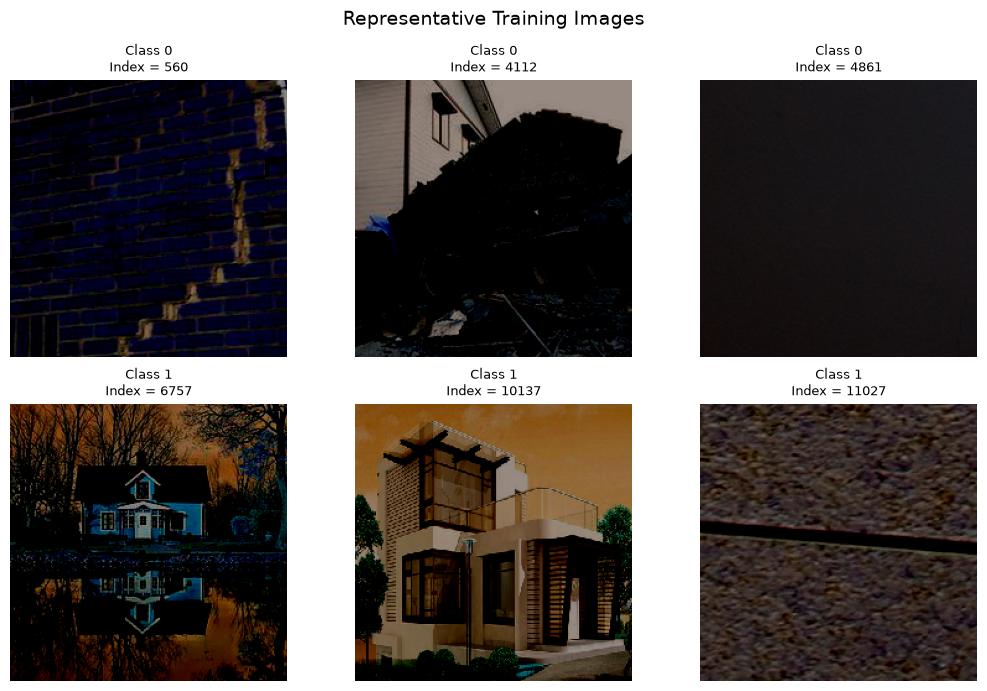


══════════════════════════════════════════════════════════════════════
TASK 7 COMPLETE ✓
══════════════════════════════════════════════════════════════════════
Classes visualized: 2
Images per class: up to 3
✓ Images were read directly from the memory-mapped training array.
✓ Full X_train was not copied into RAM.
✓ Class 0 / Class 1 names are kept neutral until the PEER README confirms the mapping.


In [17]:
# ── Task 7: Sample Image Visualization ───────────────────────────────────────
#
# Display 3 representative images per class from the training pool.
# Uses fixed-seed sampling.
# X_train is memory-mapped, so only selected images are read.
#
# Class names are kept as Class 0 / Class 1 until the PEER README
# confirms the exact semantic mapping.


import numpy as np
import matplotlib.pyplot as plt


# ── Configuration ─────────────────────────────────────────────────────────────

N_SAMPLES_PER_CLASS = 3
SEED = 42

rng = np.random.default_rng(SEED)


# ── Make sure required variables exist ────────────────────────────────────────

if "X_train" not in globals():

    X_train = np.load(
        DATA_DIR / "task2_damage_state_2" / "task2_X_train.npy",
        mmap_mode="r"
    )

if "y_train" not in globals():

    y_train = np.load(
        DATA_DIR / "task2_damage_state_1" / "task2_y_train.npy"
    )


# ── Convert one-hot labels to class IDs ───────────────────────────────────────

if y_train.ndim == 2:
    train_class_ids = np.argmax(y_train, axis=1)
else:
    train_class_ids = y_train.astype(int)


# ── Determine available classes ───────────────────────────────────────────────

class_ids = sorted(np.unique(train_class_ids).tolist())

class_names = {
    cls_id: f"Class {cls_id}"
    for cls_id in class_ids
}


# ── Select representative indices ─────────────────────────────────────────────

selected = {}

for cls_id in class_ids:

    cls_indices = np.where(
        train_class_ids == cls_id
    )[0]

    n_available = len(cls_indices)

    if n_available == 0:
        selected[cls_id] = []
        continue

    n_pick = min(
        N_SAMPLES_PER_CLASS,
        n_available
    )

    chosen = rng.choice(
        cls_indices,
        size=n_pick,
        replace=False
    )

    selected[cls_id] = sorted(
        chosen.tolist()
    )


# ── Print selected indices ────────────────────────────────────────────────────

print("\n" + "═" * 70)
print("SELECTED REPRESENTATIVE SAMPLES")
print("═" * 70)

for cls_id in class_ids:

    print(
        f"{class_names[cls_id]}: "
        f"{selected[cls_id]}"
    )


# ── Grid dimensions ──────────────────────────────────────────────────────────

valid_classes = [
    cls_id
    for cls_id in class_ids
    if len(selected[cls_id]) > 0
]

n_rows = len(valid_classes)
n_cols = max(
    [len(selected[c]) for c in valid_classes],
    default=0
)


# ── Display images ────────────────────────────────────────────────────────────

if n_rows == 0 or n_cols == 0:

    print("\n⚠ No images available for visualization.")

else:

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(
            max(10, n_cols * 3.5),
            max(6, n_rows * 3.5)
        )
    )

    # Convert axes into a consistent 2-D structure
    axes = np.asarray(axes, dtype=object)

    if axes.ndim == 0:
        axes = axes.reshape(1, 1)

    elif axes.ndim == 1:

        if n_rows == 1:
            axes = axes.reshape(1, -1)
        else:
            axes = axes.reshape(-1, 1)


    # ── Plot each class ───────────────────────────────────────────────────────

    for row, cls_id in enumerate(valid_classes):

        idx_list = selected[cls_id]

        # Read ONLY selected images from memory-mapped dataset
        images = np.asarray(
            X_train[idx_list]
        )

        for col, (arr_idx, img) in enumerate(
            zip(idx_list, images)
        ):

            ax = axes[row, col]

            # Grayscale image
            if img.ndim == 2:

                display_img = img

                ax.imshow(
                    display_img,
                    cmap="gray"
                )

            # Grayscale with channel dimension
            elif (
                img.ndim == 3
                and img.shape[-1] == 1
            ):

                display_img = img.squeeze(-1)

                ax.imshow(
                    display_img,
                    cmap="gray"
                )

            # RGB image
            else:

                if img.dtype == np.uint8:

                    display_img = img

                else:

                    # Handle [0, 1] or [0, 255] images
                    img_min = img.min()
                    img_max = img.max()

                    if img_max <= 1.0:

                        display_img = np.clip(
                            img,
                            0,
                            1
                        )

                    else:

                        display_img = np.clip(
                            img,
                            0,
                            255
                        ).astype(np.uint8)

                ax.imshow(display_img)

            ax.set_title(
                f"{class_names[cls_id]}\n"
                f"Index = {arr_idx}",
                fontsize=9
            )

            ax.axis("off")


        # Hide unused columns
        for col in range(
            len(idx_list),
            n_cols
        ):

            axes[row, col].axis("off")


    # ── Final chart formatting ────────────────────────────────────────────────

    plt.suptitle(
        "Representative Training Images",
        fontsize=14
    )

    plt.tight_layout()

    plt.show()


# ── Final summary ─────────────────────────────────────────────────────────────

print("\n" + "═" * 70)
print("TASK 7 COMPLETE ✓")
print("═" * 70)

print(
    f"Classes visualized: {len(valid_classes)}"
)

print(
    f"Images per class: "
    f"up to {N_SAMPLES_PER_CLASS}"
)

print(
    "✓ Images were read directly from the memory-mapped "
    "training array."
)

print(
    "✓ Full X_train was not copied into RAM."
)

print(
    "✓ Class 0 / Class 1 names are kept neutral until "
    "the PEER README confirms the mapping."
)

## 8. Train/Validation/Test Split

In [19]:
# ── Task 8: Train / Validation / Test Split ───────────────────────────────────
#
# Uses:
#   X_train → training images
#   y_train → training labels
#   X_test  → official test images
#   y_test  → official test labels
#
# The official test set is NOT modified.
# Only the training pool is split into train and validation sets.
# The split is stratified to preserve class proportions.


import numpy as np
from sklearn.model_selection import train_test_split


# ══════════════════════════════════════════════════════════════════════════════
# 1. CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════

SEED = 42
VAL_FRACTION = 0.15

if not (0.05 < VAL_FRACTION < 0.50):
    raise ValueError(
        f"VAL_FRACTION={VAL_FRACTION} is outside "
        f"the valid range (0.05, 0.50)."
    )


# ══════════════════════════════════════════════════════════════════════════════
# 2. MAKE SURE LABELS ARE AVAILABLE
# ══════════════════════════════════════════════════════════════════════════════

if "y_train" not in globals():

    y_train = np.load(
        DATA_DIR
        / "task2_damage_state_1"
        / "task2_y_train.npy"
    )

    print("✓ y_train loaded.")


if "y_test" not in globals():

    y_test = np.load(
        DATA_DIR
        / "task2_damage_state_1"
        / "task2_y_test.npy"
    )

    print("✓ y_test loaded.")


# ══════════════════════════════════════════════════════════════════════════════
# 3. CONVERT ONE-HOT LABELS TO CLASS IDs
# ══════════════════════════════════════════════════════════════════════════════
#
# Original labels have shape (N, 2).
# Example:
#   [1, 0] → Class 0
#   [0, 1] → Class 1
#
# We convert them to:
#   0
#   1
#
# This is required for stratified splitting and later ML models.


if y_train.ndim == 2:

    y_train_ids = np.argmax(
        y_train,
        axis=1
    )

else:

    y_train_ids = y_train.astype(int)


if y_test.ndim == 2:

    y_test_ids = np.argmax(
        y_test,
        axis=1
    )

else:

    y_test_ids = y_test.astype(int)


# ══════════════════════════════════════════════════════════════════════════════
# 4. CREATE STRATIFIED TRAIN / VALIDATION SPLIT
# ══════════════════════════════════════════════════════════════════════════════

pool_indices = np.arange(
    len(y_train_ids)
)


train_idx, val_idx = train_test_split(

    pool_indices,

    test_size=VAL_FRACTION,

    stratify=y_train_ids,

    random_state=SEED
)


# ══════════════════════════════════════════════════════════════════════════════
# 5. STORE LABEL ARRAYS FOR EACH SPLIT
# ══════════════════════════════════════════════════════════════════════════════

y_train_split = y_train_ids[train_idx]

y_val_split = y_train_ids[val_idx]

# Official test labels remain completely unchanged.
y_test_split = y_test_ids


# ══════════════════════════════════════════════════════════════════════════════
# 6. SPLIT REPORT FUNCTION
# ══════════════════════════════════════════════════════════════════════════════

def split_report(
    split_name,
    y_labels
):

    n = len(y_labels)

    class_ids = sorted(
        np.unique(y_labels).tolist()
    )

    print(
        f"\n── {split_name} "
        f"(n={n:,}) ──"
    )

    print(
        f"{'Class':<15}"
        f"{'Count':>10}"
        f"{'Percentage':>15}"
    )

    print(
        "─" * 40
    )

    for cls_id in class_ids:

        count = int(
            np.sum(
                y_labels == cls_id
            )
        )

        percentage = (
            100.0 * count / n
            if n > 0
            else 0.0
        )

        print(
            f"Class {cls_id:<9}"
            f"{count:>10,}"
            f"{percentage:>14.2f}%"
        )

    print(
        "─" * 40
    )

    print(
        f"{'Total':<15}"
        f"{n:>10,}"
        f"{'100.00%':>15}"
    )


# ══════════════════════════════════════════════════════════════════════════════
# 7. PRINT SUMMARY
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "═" * 65)

print(
    "TRAIN / VALIDATION / TEST SPLIT SUMMARY"
)

print("═" * 65)

print(
    f"Training pool size : "
    f"{len(pool_indices):,}"
)

print(
    f"Validation fraction: "
    f"{VAL_FRACTION}"
)

print(
    f"Random seed        : "
    f"{SEED}"
)


# Reports
split_report(
    "Train",
    y_train_split
)

split_report(
    "Validation",
    y_val_split
)

split_report(
    "Test",
    y_test_split
)


# ══════════════════════════════════════════════════════════════════════════════
# 8. INDEX / SAMPLE COUNTS
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "═" * 65)

print(
    f"train_idx : "
    f"{len(train_idx):,} indices"
)

print(
    f"val_idx   : "
    f"{len(val_idx):,} indices"
)

print(
    f"test set  : "
    f"{len(y_test_split):,} samples "
    f"(official test set)"
)

print("═" * 65)


# ══════════════════════════════════════════════════════════════════════════════
# 9. VERIFY SPLIT SIZES
# ══════════════════════════════════════════════════════════════════════════════

assert len(train_idx) + len(val_idx) == len(y_train_ids)

assert len(y_train_split) == len(train_idx)

assert len(y_val_split) == len(val_idx)

assert len(y_test_split) == len(y_test_ids)


print("\n✓ Train + validation = original training pool.")

print("✓ Validation split is stratified.")

print("✓ Official test set remains untouched.")

print("✓ Task 8 COMPLETE.")


═════════════════════════════════════════════════════════════════
TRAIN / VALIDATION / TEST SPLIT SUMMARY
═════════════════════════════════════════════════════════════════
Training pool size : 11,811
Validation fraction: 0.15
Random seed        : 42

── Train (n=10,039) ──
Class               Count     Percentage
────────────────────────────────────────
Class 0             5,340         53.19%
Class 1             4,699         46.81%
────────────────────────────────────────
Total              10,039        100.00%

── Validation (n=1,772) ──
Class               Count     Percentage
────────────────────────────────────────
Class 0               942         53.16%
Class 1               830         46.84%
────────────────────────────────────────
Total               1,772        100.00%

── Test (n=1,460) ──
Class               Count     Percentage
────────────────────────────────────────
Class 0               745         51.03%
Class 1               715         48.97%
───────────────────

## 9. Image Preprocessing

Images are kept in their original **224 × 224 RGB** format for HOG extraction. To avoid creating another multi-GB copy of the dataset, normalization is performed **batch-by-batch** during feature extraction rather than saving full normalized image arrays.

In [ ]:
# ── Task 9: Memory-Safe Image Preprocessing Helper ────────────────────────────

def preprocess_image_for_hog(img):
    """Convert one uint8 RGB image from [0,255] to float32 [0,1]."""

    img = img.astype(np.float32) / 255.0

    # Ensure three channels
    if img.ndim == 2:
        img = np.stack([img] * 3, axis=-1)
    elif img.shape[-1] == 1:
        img = np.repeat(img, 3, axis=-1)

    return img


print("✓ Images will be normalized batch-by-batch during HOG extraction.")
print("✓ No full normalized image arrays are created.")
print("✓ Original image size remains 224 × 224 × 3.")


## 10. HOG Feature Engineering for Classical ML

HOG (Histogram of Oriented Gradients) is used to convert each building image into a feature vector based on local edge and gradient information. These features are used by the classical ML models such as SVM and Logistic Regression.

In [ ]:
# ── Task 10A: HOG Feature Extraction ─────────────────────────────────────────

def extract_hog_features(X_source, indices, split_name):
    """Extract HOG features batch-by-batch without creating full image copies."""

    n_total = len(indices)
    feature_list = []

    print(f"Extracting HOG features for '{split_name}': {n_total} samples ...")

    for batch_start in range(0, n_total, BATCH_SIZE):
        batch_end = min(batch_start + BATCH_SIZE, n_total)
        batch_indices = indices[batch_start:batch_end]

        for idx in batch_indices:
            img = preprocess_image_for_hog(X_source[idx])

            feat = skimage_hog(
                img,
                pixels_per_cell=HOG_PIXELS_PER_CELL,
                cells_per_block=HOG_CELLS_PER_BLOCK,
                orientations=HOG_ORIENTATIONS,
                channel_axis=-1,
                feature_vector=True
            )

            feature_list.append(feat)

        print(f"    ... {batch_end}/{n_total} samples done.")

    features = np.stack(feature_list, axis=0).astype(np.float32)

    print(
        f"  '{split_name}' HOG done → "
        f"shape={features.shape}, dtype={features.dtype}"
    )

    return features


# Train and validation use the same original training pool.
X_train_hog = extract_hog_features(
    X_train,
    train_idx,
    "Train"
)

X_val_hog = extract_hog_features(
    X_train,
    val_idx,
    "Validation"
)

# Official test set remains untouched.
test_idx = np.arange(len(X_test))

X_test_hog = extract_hog_features(
    X_test,
    test_idx,
    "Test"
)

print(f"\nHOG feature vector dimensionality: {X_train_hog.shape[1]}")


Extracting HOG features for 'Train': 10039 samples ...
    ... 256/10039 samples done.
    ... 512/10039 samples done.
    ... 768/10039 samples done.
    ... 1024/10039 samples done.
    ... 2048/10039 samples done.
    ... 4096/10039 samples done.
    ... 8192/10039 samples done.
    ... 10039/10039 samples done.
  'Train' HOG done → shape=(10039, 26244), dtype=float32
  'Validation' HOG done → shape=(1772, 26244), dtype=float32
  'Test' HOG done → shape=(1460, 26244), dtype=float32

HOG feature vector dimensionality: 26244


In [ ]:
# ── Task 10B: Memory-Safe HOG Scaling ─────────────────────────────────────────

print("═" * 65)
print("  Memory-Safe HOG Feature Scaling")
print("═" * 65)

print(f"Train HOG shape      : {X_train_hog.shape}")
print(f"Validation HOG shape : {X_val_hog.shape}")
print(f"Test HOG shape       : {X_test_hog.shape}")


# Fit scaler on training features only
print("\n1. Fitting StandardScaler incrementally...")

hog_scaler = StandardScaler()

for start in range(0, len(X_train_hog), BATCH_SIZE):
    end = min(start + BATCH_SIZE, len(X_train_hog))
    hog_scaler.partial_fit(X_train_hog[start:end])
    print(f"  ... fitted {end}/{len(X_train_hog)} samples")

print("✓ StandardScaler fitted on training HOG features only.")


# Disk-backed scaled arrays prevent another large RAM allocation
hog_train_path = RESULTS_DIR / "X_train_hog.npy"
hog_val_path = RESULTS_DIR / "X_val_hog.npy"
hog_test_path = RESULTS_DIR / "X_test_hog.npy"

X_train_hog_scaled = np.lib.format.open_memmap(
    hog_train_path, mode="w+", dtype=np.float32, shape=X_train_hog.shape
)

X_val_hog_scaled = np.lib.format.open_memmap(
    hog_val_path, mode="w+", dtype=np.float32, shape=X_val_hog.shape
)

X_test_hog_scaled = np.lib.format.open_memmap(
    hog_test_path, mode="w+", dtype=np.float32, shape=X_test_hog.shape
)


def scale_to_memmap(X_source, X_destination, split_name):
    print(f"\nScaling {split_name} HOG features...")

    for start in range(0, len(X_source), BATCH_SIZE):
        end = min(start + BATCH_SIZE, len(X_source))

        batch_scaled = hog_scaler.transform(X_source[start:end])
        X_destination[start:end] = batch_scaled.astype(np.float32)

        print(f"  ... {end}/{len(X_source)} samples scaled")

    X_destination.flush()


scale_to_memmap(X_train_hog, X_train_hog_scaled, "training")
scale_to_memmap(X_val_hog, X_val_hog_scaled, "validation")
scale_to_memmap(X_test_hog, X_test_hog_scaled, "test")


# Save scaler
scaler_path = RESULTS_DIR / "hog_scaler.pkl"
joblib.dump(hog_scaler, scaler_path)

print("\n" + "═" * 65)
print("HOG Feature Engineering Complete")
print("═" * 65)
print(f"Train scaled shape      : {X_train_hog_scaled.shape}")
print(f"Validation scaled shape : {X_val_hog_scaled.shape}")
print(f"Test scaled shape       : {X_test_hog_scaled.shape}")
print(f"Feature dimension       : {X_train_hog_scaled.shape[1]}")
print(f"Scaler saved            : {scaler_path}")
print("✓ StandardScaler fitted on training data only.")
print("✓ Scaled arrays saved to results/.")
print("═" * 65)


═════════════════════════════════════════════════════════════════
  Memory-Safe HOG Feature Scaling
═════════════════════════════════════════════════════════════════
Train HOG shape      : (10039, 26244)
Validation HOG shape : (1772, 26244)
Test HOG shape       : (1460, 26244)

1. Fitting StandardScaler incrementally...
✓ StandardScaler fitted on training HOG features only.

2. Scaling training HOG features...
  ... 10039/10039 samples scaled

3. Scaling validation HOG features...
  ... 1772/1772 samples scaled

4. Scaling test HOG features...
  ... 1460/1460 samples scaled

═════════════════════════════════════════════════════════════════
HOG Feature Engineering Complete
═════════════════════════════════════════════════════════════════
Train scaled shape      : (10039, 26244)
Validation scaled shape : (1772, 26244)
Test scaled shape       : (1460, 26244)
Feature dimension       : 26244
Scaler saved            : ../results/hog_scaler.pkl
✓ StandardScaler fitted on training data only.
✓

## 11. HOG Feature Visualization

In [ ]:
# ── Task 11: HOG Visualization ───────────────────────────────────────────────

sample_idx = train_idx[0]
sample_img = preprocess_image_for_hog(X_train[sample_idx])

_, hog_image = skimage_hog(
    sample_img,
    pixels_per_cell=HOG_PIXELS_PER_CELL,
    cells_per_block=HOG_CELLS_PER_BLOCK,
    orientations=HOG_ORIENTATIONS,
    channel_axis=-1,
    feature_vector=True,
    visualize=True
)

hog_image_rescaled = exposure.rescale_intensity(
    hog_image,
    in_range=(0, 10)
)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(np.clip(sample_img, 0, 1))
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(hog_image_rescaled, cmap="gray")
axes[1].set_title("HOG Visualization")
axes[1].axis("off")

plt.suptitle("HOG Feature Visualization")
plt.tight_layout()
plt.show()

print("✓ HOG visualization generated.")


✓ HOG visualization generated.


## 12. Data Leakage Checks

In [ ]:
# ── Task 12: Data Leakage Checks ─────────────────────────────────────────────

print("═" * 60)
print("  Data Leakage Checks")
print("═" * 60)

leakage_found = False

# 1. Train/validation disjoint
train_idx_set = set(train_idx.tolist())
val_idx_set = set(val_idx.tolist())

overlap_tv = train_idx_set & val_idx_set

if overlap_tv:
    print(f"✗ LEAKAGE DETECTED: {len(overlap_tv)} overlapping indices.")
    leakage_found = True
else:
    print(
        f"✓ Train ∩ Validation = ∅ "
        f"(train={len(train_idx_set)}, validation={len(val_idx_set)})"
    )

# 2. Train + validation cover the complete training pool
if len(train_idx) + len(val_idx) != len(X_train):
    print("✗ SPLIT ERROR: train + validation do not cover the training pool.")
    leakage_found = True
else:
    print(
        f"✓ Train + Validation = complete training pool "
        f"({len(train_idx) + len(val_idx)} = {len(X_train)})"
    )

# 3. Official test set is structurally separate
print(
    f"✓ Official test set is separate from the training pool "
    f"({len(X_test)} test samples)."
)

# 4. Scaler fitted on training data only
if "hog_scaler" in globals():
    expected_n = len(train_idx)
    actual_n = int(hog_scaler.n_samples_seen_)

    if actual_n != expected_n:
        print(
            f"✗ SCALER LEAKAGE: scaler saw {actual_n} samples; "
            f"expected {expected_n}."
        )
        leakage_found = True
    else:
        print(
            f"✓ StandardScaler fitted on training features only "
            f"({actual_n} samples)."
        )
else:
    print("✗ hog_scaler not found.")
    leakage_found = True

print("─" * 60)

if leakage_found:
    raise AssertionError("Data leakage or split inconsistency detected.")
else:
    print("✓ No data leakage detected")

print("═" * 60)


════════════════════════════════════════════════════════════════════
  Data Leakage Checks
════════════════════════════════════════════════════════════════════
✓ Train ∩ Validation = ∅ (train=10039, validation=1772)
✓ Train + Validation = complete training pool (11811 = 11811)
✓ Official test set is separate from the training pool (1460 test samples).
✓ StandardScaler fitted on training features only (10039 samples).
────────────────────────────────────────────────────────────────────
✓ No data leakage detected
════════════════════════════════════════════════════════════════════


## 13. Final Preprocessing Summary

In [ ]:
# ── Task 13: Final Preprocessing Summary ─────────────────────────────────────

sep = "═" * 65
sep2 = "─" * 65

print(sep)
print("  FINAL PREPROCESSING SUMMARY")
print(sep)

print("\n1. Selected Dataset")
print(sep2)
print(f"  Dataset : {SELECTED_DATASET}")
print(
    "  The PEER Task 2 data provides labelled training and test arrays "
    "for supervised binary classification."
)
print(
    "  The training pool was split into train and validation subsets "
    "using stratification; the official test set remained untouched."
)

print("\n2. Split Counts")
print(sep2)

def summary_split_row(split_name, y_labels):
    n = len(y_labels)
    rows = ""

    for cls_id in sorted(np.unique(y_labels)):
        count = int(np.sum(y_labels == cls_id))
        pct = 100.0 * count / n
        rows += (
            f"  {split_name:<14} Class {cls_id:<6} "
            f"{count:>8} {pct:>9.2f}%\n"
        )

    rows += f"  {split_name:<14} {'Total':<12} {n:>8} {'100.00%':>10}\n"
    return rows

print(f"  {'Split':<14} {'Class':<12} {'Count':>8} {'%':>10}")
print(f"  {'─'*14} {'─'*12} {'─'*8} {'─'*10}")

print(summary_split_row("Train", y_train_split), end="")
print(summary_split_row("Validation", y_val_split), end="")
print(summary_split_row("Test", y_test_split), end="")

print("\n3. Original Image Properties")
print(sep2)

_, H, W, C = X_train.shape

print(f"  Dimensions : {H} × {W}")
print(f"  Channels   : {C}")
print(f"  dtype      : {X_train.dtype}")
print("  Raw pixels : uint8 [0, 255]")
print("  Normalization: applied batch-by-batch during HOG extraction.")

print("\n4. Preprocessing Pipeline")
print(sep2)

steps = [
    "1. Verified dataset files and metadata",
    "2. Loaded large training images using memory mapping",
    "3. Inspected shapes, dtypes, and pixel ranges",
    "4. Calculated class distributions",
    "5. Compared Task 2_1 and Task 2_2 contents",
    "6. Created stratified train/validation split (15%, SEED=42)",
    "7. Kept the official test set untouched",
    "8. Normalized images batch-by-batch to [0,1]",
    "9. Extracted HOG features",
    "10. Applied StandardScaler fitted on training features only",
    "11. Saved scaled HOG features and scaler",
    "12. Checked for data leakage",
]

for step in steps:
    print(f"  {step}")

print("\n5. HOG Feature Engineering")
print(sep2)

print("  Method              : HOG (Histogram of Oriented Gradients)")
print(f"  pixels_per_cell     : {HOG_PIXELS_PER_CELL}")
print(f"  cells_per_block     : {HOG_CELLS_PER_BLOCK}")
print(f"  orientations        : {HOG_ORIENTATIONS}")
print(f"  Feature vector size : {X_train_hog_scaled.shape[1]}")
print("  Scaler              : StandardScaler (training only)")

print("\n6. Saved Outputs")
print(sep2)

print("  results/X_train_hog.npy")
print("  results/X_val_hog.npy")
print("  results/X_test_hog.npy")
print("  results/hog_scaler.pkl")

print("\n7. Final Status")
print(sep2)

print("  ✓ Dataset preprocessing complete")
print("  ✓ HOG feature engineering complete")
print("  ✓ Data leakage checks complete")
print("  ✓ Ready for classical ML models:")
print("      - SVM")
print("      - Logistic Regression")

print("\n" + sep)
print("PREPROCESSING NOTEBOOK COMPLETE ✓")
print(sep)


═════════════════════════════════════════════════════════════════
  FINAL PREPROCESSING SUMMARY
═════════════════════════════════════════════════════════════════

1. Selected Dataset
─────────────────────────────────────────────────────────────────
  Dataset : Task_2_1
  The PEER Task 2 data provides labelled training and test arrays for supervised binary classification.
  The training pool was split into train and validation subsets using stratification; the official test set remained untouched.

2. Split Counts
─────────────────────────────────────────────────────────────────
  Train          Class 0          5340     53.19%
  Train          Class 1          4699     46.81%
  Train          Total           10039    100.00%
  Validation     Class 0           942     53.16%
  Validation     Class 1           830     46.84%
  Validation     Total            1772    100.00%
  Test           Class 0           745     51.03%
  Test           Class 1           715     48.97%
  Test         